C:\Users\wzimm\Desktop\microPAM_data\1B7D3C2E_20260304\00\1B7D3C2E_20260304_000200.bin
96000 60.074666666666666


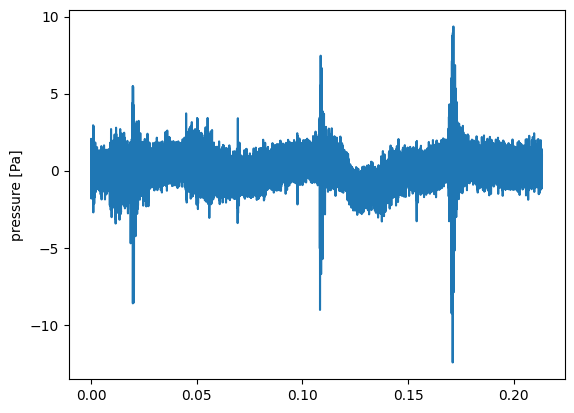

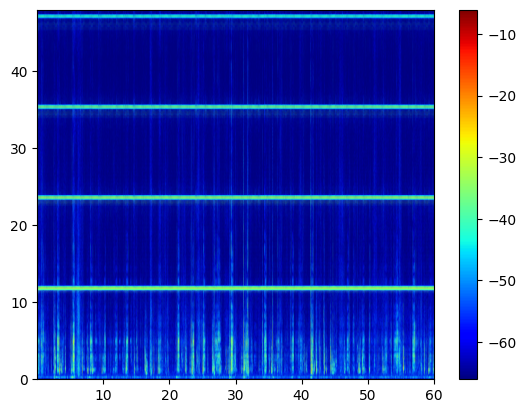

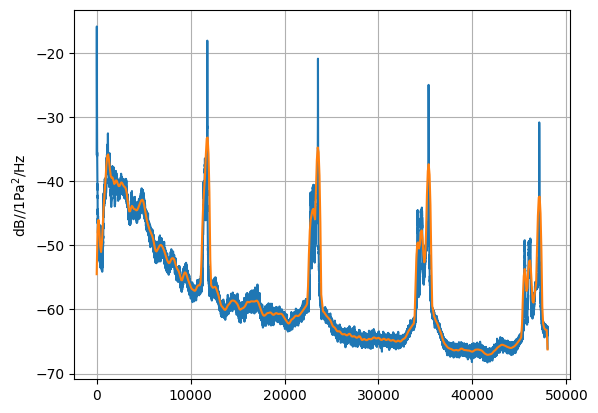

In [1]:
import os

root=os.path.join(os.environ['HOMEPATH'],'Desktop') # for windows
#
fname=os.path.join(root,'1B30112D_20260102_212400.bin')

fname=os.path.join('D:','135B2326_20260201','10','135B2326_20260201_104600.bin')
fname=os.path.join('C:\\Users','wzimm','Desktop','microPAM_data','1B7D3C2E_20260304','00',
                   '1B7D3C2E_20260304_000200.bin')
print(fname)
import numpy as np
import microPAM as pam
fs,data = pam.load_microPAM(fname)
td = np.arange(data.shape[0])/fs
print(fs,data.shape[0]/fs)

# calibrate data
cal=-80 # dB//1V/Pa         # 1 Pa generates 10^-4 V (-80 dB) (-200 dB//uPa)
data /= 10**(cal/20)

ich=0 # selected channel
data=data[:,ich]

import matplotlib.pyplot as plt
dsel=(1*16+4)*1024
plt.plot(td[:dsel],data[:dsel])
#plt.plot(td,data)
plt.ylabel('pressure [Pa]')
plt.show()

import scipy.signal as signal
nw=512
f,t,q=signal.spectrogram(data,fs=fs,window='hann',nperseg=nw,noverlap=nw//2,nfft=nw*2,scaling='density')

U=np.mean(q,axis=1)
fu=f.copy()

Q=10*np.log10(np.abs(q))
qmax=np.max(Q)

ext=[t[0],t[-1],f[0]/1000,f[-1]/1000]
clim=[qmax-60,qmax]
#
plt.imshow(Q, aspect='auto',origin='lower', extent=ext,cmap='jet',clim=clim)
plt.colorbar()
plt.show()

nw=64*1024
f,q=signal.welch(data,fs=fs,window='hann',nperseg=nw,noverlap=nw//2,nfft=nw*2,scaling='density')
#
plt.plot(f,10*np.log10(q))
plt.plot(fu,10*np.log10(U))
plt.ylabel('dB//1Pa$^2$/Hz')
#plt.xlim(0,200)
plt.grid(True)
plt.show()
